# ch236 — Vector Calculus: Divergence and Curl

**Advanced Calculus Experiment 6.**

When functions output vectors *(Part V)*, differentiation produces new vector operators: **divergence** measures outward flow at a point, **curl** measures rotation. These are the mathematical tools of fluid dynamics, electromagnetism, and — less obviously — understanding how gradients flow in neural networks.

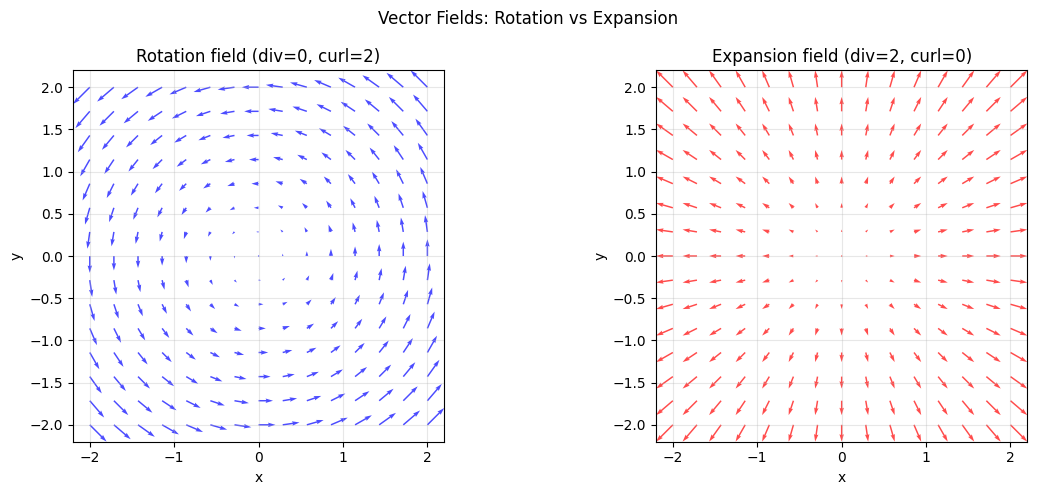

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Vector field: F(x,y) = (-y, x) — pure rotation
def F_rotate(x, y): return -y, x
# Divergence: dFx/dx + dFy/dy = 0 + 0 = 0 (incompressible)
# Curl: dFy/dx - dFx/dy = 1 - (-1) = 2 (constant rotation)

# Vector field: F(x,y) = (x, y) — pure expansion
def F_expand(x, y): return x, y
# Divergence: 1 + 1 = 2 (expanding flow)
# Curl: 0 - 0 = 0 (no rotation)

x_g = np.linspace(-2, 2, 15)
y_g = np.linspace(-2, 2, 15)
X, Y = np.meshgrid(x_g, y_g)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, field_fn, title, color in zip(axes,
        [F_rotate, F_expand],
        ['Rotation field (div=0, curl=2)', 'Expansion field (div=2, curl=0)'],
        ['blue', 'red']):
    U, V = field_fn(X, Y)
    ax.quiver(X, Y, U, V, color=color, alpha=0.7)
    ax.set_title(title); ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.grid(True, alpha=0.3)

plt.suptitle('Vector Fields: Rotation vs Expansion', fontsize=12)
plt.tight_layout(); plt.savefig('ch236_vector_fields.png', dpi=100); plt.show()


In [2]:
# Numerically compute divergence and curl
def numerical_divergence(Fx_fn, Fy_fn, x, y, h=1e-5):
    dFx_dx = (Fx_fn(x+h, y) - Fx_fn(x-h, y)) / (2*h)
    dFy_dy = (Fy_fn(x, y+h) - Fy_fn(x, y-h)) / (2*h)
    return dFx_dx + dFy_dy

def numerical_curl_z(Fx_fn, Fy_fn, x, y, h=1e-5):
    dFy_dx = (Fy_fn(x+h, y) - Fy_fn(x-h, y)) / (2*h)
    dFx_dy = (Fx_fn(x, y+h) - Fx_fn(x, y-h)) / (2*h)
    return dFy_dx - dFx_dy

# Evaluate at a few points
pts = [(0, 1), (1, 0), (-1, 1)]
print("Point        |  div(rotate) |  curl(rotate) |  div(expand) |  curl(expand)")
print("-" * 72)
for (px, py) in pts:
    dr = numerical_divergence(lambda x,y: F_rotate(x,y)[0], lambda x,y: F_rotate(x,y)[1], px, py)
    cr = numerical_curl_z(lambda x,y: F_rotate(x,y)[0], lambda x,y: F_rotate(x,y)[1], px, py)
    de = numerical_divergence(lambda x,y: F_expand(x,y)[0], lambda x,y: F_expand(x,y)[1], px, py)
    ce = numerical_curl_z(lambda x,y: F_expand(x,y)[0], lambda x,y: F_expand(x,y)[1], px, py)
    print(f"({px:+.1f}, {py:+.1f})   | {dr:>12.2f} | {cr:>13.2f} | {de:>12.2f} | {ce:>12.2f}")


Point        |  div(rotate) |  curl(rotate) |  div(expand) |  curl(expand)
------------------------------------------------------------------------
(+0.0, +1.0)   |         0.00 |          2.00 |         2.00 |         0.00
(+1.0, +0.0)   |         0.00 |          2.00 |         2.00 |         0.00
(-1.0, +1.0)   |         0.00 |          2.00 |         2.00 |         0.00


## Summary

| Operator | Formula | Meaning |
|---|---|---|
| Gradient | del f | Direction of steepest ascent |
| Divergence | del . F | Net outward flow at a point |
| Curl | del x F | Rotational tendency at a point |
| Laplacian | del^2 f | Sum of second partial derivatives |

**Forward reference:** The Laplacian operator (divergence of gradient) appears in physics-informed neural networks and graph neural networks *(Part IX advanced topics)*.